# MDC calculation — speech-only and demographics-only

Based on MDC_calculation_equivalence_test_and_SEM_analysis.ipynb

In [27]:
import pandas as pd
import numpy as np
import sklearn.metrics as sk_metrics
from scipy.stats import pearsonr
from scipy import stats
import matplotlib.pyplot as plt
import pingouin as pg
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import chi2 as chi2_dist
from semopy import Model, calc_stats

from datetime import datetime
now = lambda: datetime.now().strftime("%Y-%m-%d %H:%M")

In [28]:
VERSION = 'kw19_withoutCohortB'
VERSION = 'demographics_only'
#VERSION = 'speech_only'
#VERSION = 'linguistic_only'

n_bootsrap_samples = 10000

# Cohort definitions: (label, wave_a, wave_b)
COHORTS = [
    ('A', 'wave1', 'wave2'),
    ('B', 'wave2', 'wave3'),
]

target = 'language'
#target = 'memory'
#target = 'executive_function'
#target = 'speed'

results = {'A': {}, 'B': {}}

## Load longitudinal data for both cohorts

In [29]:
def load_longitudinal(version, cohort_label):
    path = f"transformed_data/{version}_predictions_targets_longitudinal_cohort{cohort_label}.csv"
    return pd.read_csv(path, header=[0, 1, 2], index_col=0)


longitudinal_by_cohort = {
    label: load_longitudinal(VERSION, label) for label, _, _ in COHORTS
}

for label, wave_a, wave_b in COHORTS:
    print(f'Cohort {label} ({wave_a} ↔ {wave_b}): shape = {longitudinal_by_cohort[label].shape}')
    results[label]['n'] = longitudinal_by_cohort[label].shape[0]

Cohort A (wave1 ↔ wave2): shape = (305, 40)
Cohort B (wave2 ↔ wave3): shape = (70, 40)


## Test-retest reliability (ICC) of targets and predictions

In [30]:
def calculate_test_retest(longitudinal, target, wave_a, wave_b):
    test_retest_data_long = pd.DataFrame({
        'score': pd.concat((
            longitudinal[(wave_a, target, 'target')],
            longitudinal[(wave_b, target, 'target')],
        ), axis=0, ignore_index=True),
        'time': pd.concat((
            pd.Series(wave_a, index=longitudinal.index),
            pd.Series(wave_b, index=longitudinal.index),
        ), axis=0, ignore_index=True),
        'participant': pd.concat((
            pd.Series(longitudinal.index),
            pd.Series(longitudinal.index),
        ), axis=0, ignore_index=True),
    })
    icc_result = pg.intraclass_corr(
        data=test_retest_data_long, targets='participant', raters='time',
        ratings='score', nan_policy='omit',
    )
    icc_31 = icc_result.loc[icc_result['Type'] == 'ICC3', 'ICC'].values[0]
    return icc_31


def calculate_test_retest_predictions(longitudinal, target, task, wave_a, wave_b):
    test_retest_data_long = pd.DataFrame({
        'score': pd.concat((
            longitudinal[(wave_a, target, task)],
            longitudinal[(wave_b, target, task)],
        ), axis=0, ignore_index=True),
        'time': pd.concat((
            pd.Series(wave_a, index=longitudinal.index),
            pd.Series(wave_b, index=longitudinal.index),
        ), axis=0, ignore_index=True),
        'participant': pd.concat((
            pd.Series(longitudinal.index),
            pd.Series(longitudinal.index),
        ), axis=0, ignore_index=True),
    })
    icc_result = pg.intraclass_corr(
        data=test_retest_data_long, targets='participant', raters='time',
        ratings='score', nan_policy='omit',
    )
    icc_31 = icc_result.loc[icc_result['Type'] == 'ICC3', 'ICC'].values[0]
    return icc_31


for label, wave_a, wave_b in COHORTS:
    r = calculate_test_retest(longitudinal_by_cohort[label], target, wave_a, wave_b)
    print(f'Cohort {label} ({wave_a} ↔ {wave_b}) — ICC31 ({target}): {r:.2f}')
    results[label][f'ICC_{target}'] = r

Cohort A (wave1 ↔ wave2) — ICC31 (language): 0.69
Cohort B (wave2 ↔ wave3) — ICC31 (language): 0.72


## Add average-prediction columns per cohort

In [31]:
def get_col(task, wave, target):
    return (wave, target, task)


tasks = ['cookieTheft', 'picnicScene', 'journaling']
all_targets = ['language', 'executive_function', 'speed', 'memory']


def add_average_predictions(longitudinal, wave_a, wave_b, tasks, all_targets):
    """Add per-wave avg_speech_prediction and avg_cookieTheft_picnicScene
    columns to a longitudinal frame, for every target available in the frame."""
    longitudinal = longitudinal.copy()
    for wave in [wave_a, wave_b]:
        for target_here in all_targets:
            # Only act if columns exist for this target/wave combo
            available_tasks = [
                t for t in tasks if (wave, target_here, t) in longitudinal.columns
            ]
            if not available_tasks:
                continue
            task_cols = [(wave, target_here, t) for t in available_tasks]
            longitudinal[(wave, target_here, 'avg_speech_prediction')] = (
                longitudinal[task_cols].mean(axis=1)
            )
            pic_tasks = [
                t for t in ['picnicScene', 'cookieTheft']
                if (wave, target_here, t) in longitudinal.columns
            ]
            if pic_tasks:
                pic_cols = [(wave, target_here, t) for t in pic_tasks]
                longitudinal[(wave, target_here, 'avg_cookieTheft_picnicScene')] = (
                    longitudinal[pic_cols].mean(axis=1)
                )
    return longitudinal.sort_index(axis=1, level=[0, 1, 2])


for label, wave_a, wave_b in COHORTS:
    longitudinal_by_cohort[label] = add_average_predictions(
        longitudinal_by_cohort[label], wave_a, wave_b, tasks, all_targets,
    )

longitudinal_by_cohort['A'].head()

wave1                        \
                                  executive_function                         
                         avg_cookieTheft_picnicScene avg_speech_prediction   
sample_name_longitudinal                                                     
01d1fdfc3a                                 -0.054098             -0.054097   
0367083668                                  0.249494              0.249539   
048eb2a01e                                  0.377257              0.377180   
049af4901b                                  0.006548              0.006564   
04d9f72ef8                                  0.063007              0.063083   

                                                                              \
                                                                               
                         cookieTheft journaling picnicScene    target   wave   
sample_name_longitudinal                                                       
01d1fdfc3a                 -0.054286  -0.054095   -0.053910 -0.805223  wave1   
0367083668                  0.249424   0.249631    0.249564  1.371604  wave1   
048eb2a01e                  0.377411   0.377024    0.377103  1.068259  wave1   
049af4901b                  0.006419   0.006597    0.006676  0.399128  wave1   
04d9f72ef8                  0.062813   0.063235    0.063201 -0.074194  wave1   

                                                                            \
                                            language                         
                         avg_cookieTheft_picnicScene avg_speech_prediction   
sample_name_longitudinal                                                     
01d1fdfc3a                                 -0.193994             -0.193961   
0367083668                                  0.079220              0.079244   
048eb2a01e                                  0.373773              0.373749   
049af4901b                                 -0.240687             -0.240570   
04d9f72ef8                                 -0.036395             -0.036331   

                                      ...       wave2                   \
                                      ...      memory                    
                         cookieTheft  ... picnicScene    target   wave   
sample_name_longitudinal              ...                                
01d1fdfc3a                 -0.194295  ...    0.447386 -2.676297  wave2   
0367083668                  0.079198  ...    0.426764 -0.328401  wave2   
048eb2a01e                  0.374178  ...    0.351875  1.167577  wave2   
049af4901b                 -0.240723  ...    0.158631 -0.283585  wave2   
04d9f72ef8                 -0.036491  ...    0.340979 -0.662634  wave2   

                                                                            \
                                               speed                         
                         avg_cookieTheft_picnicScene avg_speech_prediction   
sample_name_longitudinal                                                     
01d1fdfc3a                                  0.095417              0.095378   
0367083668                                  0.185061              0.185067   
048eb2a01e                                  0.327970              0.327995   
049af4901b                                  0.156606              0.156654   
04d9f72ef8                                  0.047019              0.047040   

                                                                              
                                                                              
                         cookieTheft journaling picnicScene    target   wave  
sample_name_longitudinal                                                      
01d1fdfc3a                  0.095283   0.095302    0.095551 -2.152385  wave2  
0367083668                  0.185144   0.185079    0.184978  1.470132  wave2  
048eb2a01e                  0.328252   0.328044    0.327688  0.262024  wave2

In [32]:
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) ===')
    long_df = longitudinal_by_cohort[label]
    for task in ['cookieTheft', 'picnicScene', 'journaling',
                 'avg_speech_prediction', 'avg_cookieTheft_picnicScene']:
        r_here = calculate_test_retest_predictions(long_df, target, task, wave_a, wave_b)
        print(f'  ICC31 ({target}) {task}: {r_here:.3f}')
        results[label][f'ICC_{target}_{task}'] = r_here


=== Cohort A (wave1 ↔ wave2) ===
  ICC31 (language) cookieTheft: 0.974
  ICC31 (language) picnicScene: 0.974
  ICC31 (language) journaling: 0.974
  ICC31 (language) avg_speech_prediction: 0.974
  ICC31 (language) avg_cookieTheft_picnicScene: 0.974

=== Cohort B (wave2 ↔ wave3) ===
  ICC31 (language) cookieTheft: 0.987
  ICC31 (language) picnicScene: 0.987
  ICC31 (language) journaling: 0.987
  ICC31 (language) avg_speech_prediction: 0.987
  ICC31 (language) avg_cookieTheft_picnicScene: 0.987


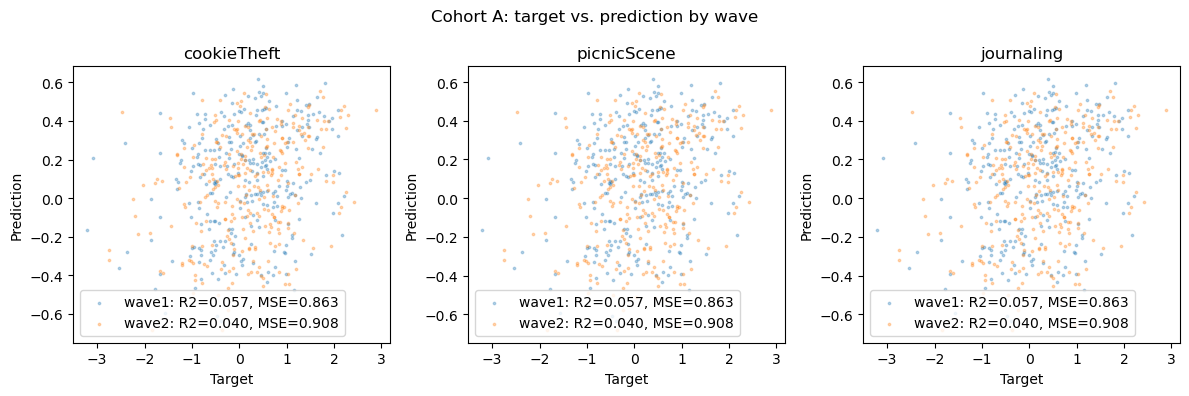

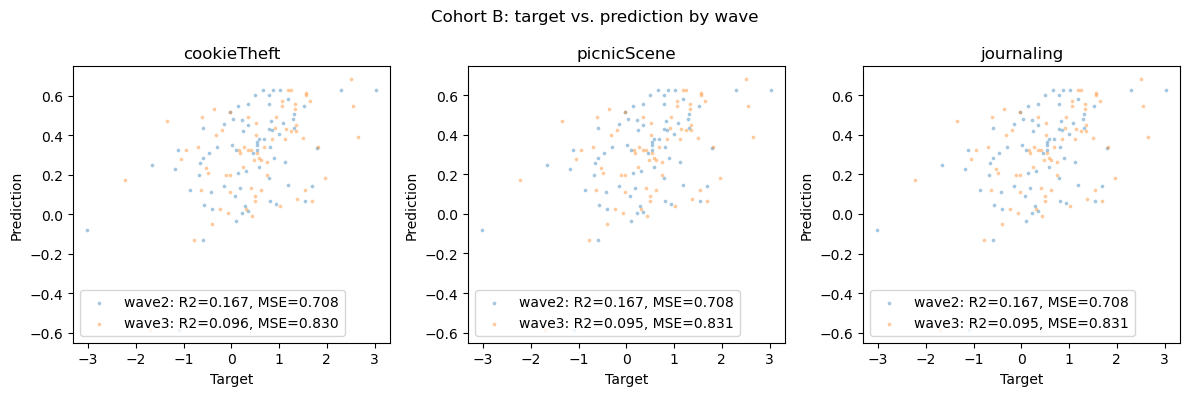

In [33]:
def plot_target_vs_prediction_scatter(longitudinal, label, wave_a, wave_b):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for task, ax in zip(['cookieTheft', 'picnicScene', 'journaling'], axes):
        for wave in [wave_a, wave_b]:
            data_here = longitudinal[
                [(wave, target, 'target'), (wave, target, task)]
            ].copy().dropna()
            r2 = r2_score(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
            )
            mse = mean_squared_error(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
            )
            ax.scatter(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
                alpha=0.3,
                label=f"{wave}: R2={r2:.3f}, MSE={mse:.3f}",
                s=3,
            )
        ax.set_title(task)
        ax.legend()
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')
    fig.suptitle(f'Cohort {label}: target vs. prediction by wave')
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_target_vs_prediction_scatter(longitudinal_by_cohort[label], label, wave_a, wave_b)

## MDC calculation with bootstrap CIs

In [34]:
import pingouin as pg


def _icc31(a, b) -> float:
    """
    ICC(3,1) via pingouin, mirroring calculate_test_retest's long-format setup.
    `a` and `b` are paired vectors (e.g. wave_a and wave_b ratings).
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = len(a)
    if n < 2:
        return np.nan
    long_df = pd.DataFrame({
        "score": np.concatenate([a, b]),
        "time": np.concatenate([np.full(n, "a"), np.full(n, "b")]),
        "participant": np.concatenate([np.arange(n), np.arange(n)]),
    })
    try:
        icc_result = pg.intraclass_corr(
            data=long_df, targets="participant", raters="time",
            ratings="score", nan_policy="omit",
        )
        return icc_result.loc[icc_result["Type"] == "ICC3", "ICC"].values[0]
    except Exception:
        return np.nan


def _icc31(a: np.ndarray, b: np.ndarray) -> float:
    """
    ICC(3,1): two-way mixed, single rater, consistency.
    Computed from one-way-within-subjects ANOVA with k=2 ratings per subject.
        ICC(3,1) = (MS_between - MS_within) / (MS_between + (k-1) * MS_within)
    Returns np.nan if degenerate.
    Much faster than pg version above
    Checked if the two agree in analyses/kw20/test_icc_pg_vs_custom.ipynb
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    n = len(a)
    if n < 2:
        return np.nan
    k = 2
    subj_means = (a + b) / 2.0
    grand_mean = (a.sum() + b.sum()) / (2 * n)
    ss_between = k * np.sum((subj_means - grand_mean) ** 2)
    ss_within = np.sum((a - subj_means) ** 2) + np.sum((b - subj_means) ** 2)
    ms_between = ss_between / (n - 1)
    ms_within = ss_within / (n * (k - 1))
    denom = ms_between + (k - 1) * ms_within
    if not np.isfinite(denom) or denom <= 0:
        return np.nan
    return (ms_between - ms_within) / denom


def calculate_mdc_with_bootstrap_CI(
    df: pd.DataFrame,
    domain: str = "language",
    tasks=("cookieTheft", "picnicScene", "journaling",
           "avg_speech_prediction", "avg_cookieTheft_picnicScene"),
    waves=("wave1", "wave2"),
    z: float = 1.96,
    n_boot: int = 2000,
    ci: float = 0.95,
    random_state: int | None = 0,
) -> pd.DataFrame:
    """
    Estimate MDC with nonparametric bootstrap CIs.
    """
    wave_a, wave_b = waves
    alpha = (1 - ci) / 2
    rng = np.random.default_rng(random_state)

    x1 = df[(wave_a, domain, "target")]
    x2 = df[(wave_b, domain, "target")]
    target_pair = pd.concat({"x1": x1, "x2": x2}, axis=1).dropna()
    if len(target_pair) < 3:
        raise ValueError("Not enough complete target pairs.")

    # Build per-task complete-case frames once
    task_frames = {}
    for task in tasks:
        y1 = df[(wave_a, domain, task)]
        y2 = df[(wave_b, domain, task)]
        tmp = pd.concat({"x1": x1, "x2": x2, "y1": y1, "y2": y2}, axis=1).dropna()
        if len(tmp) < 3:
            raise ValueError(f"Not enough complete cases for task {task!r}.")
        task_frames[task] = tmp

    # Point estimates
    var_c_hat = target_pair["x1"].cov(target_pair["x2"])
    reliability_target = target_pair["x1"].corr(target_pair["x2"])
    var_y_obs = np.mean([target_pair["x1"].var(), target_pair["x2"].var()])
    if not np.isfinite(var_c_hat) or var_c_hat <= 0:
        raise ValueError(f"Var(C) non-positive ({var_c_hat:.4f}).")
    mdc_cognitive = z * np.sqrt(2 * var_y_obs * (1 - reliability_target))
    icc_cognitive_hat = _icc31(target_pair["x1"].values, target_pair["x2"].values)

    rows = []
    for task, tmp in task_frames.items():
        n = len(tmp)
        regression_r2 = np.mean([
            sk_metrics.r2_score(tmp["x1"], tmp["y1"]),
            sk_metrics.r2_score(tmp["x2"], tmp["y2"]),
        ])
        regression_mse = np.mean([
            sk_metrics.mean_squared_error(tmp["x1"], tmp["y1"]),
            sk_metrics.mean_squared_error(tmp["x2"], tmp["y2"]),
        ])
        cov_y1_x1 = tmp["y1"].cov(tmp["x1"])
        cov_y2_x2 = tmp["y2"].cov(tmp["x2"])
        lambda_hat = np.mean([cov_y1_x1, cov_y2_x2]) / var_c_hat

        delta_yhat = tmp["y2"] - tmp["y1"]
        var_delta_yhat = delta_yhat.var()
        sd_delta_yhat = delta_yhat.std()
        sigma_epsilon_sq_hat = var_delta_yhat / 2.0
        mdc_speech_pred = z * sd_delta_yhat
        mdc_speech_latent = mdc_speech_pred / np.abs(lambda_hat)

        icc_hat = _icc31(tmp["y1"].values, tmp["y2"].values)

        rows.append({
            "task": task, "n": n,
            "regression_r2": regression_r2,
            "regression_mse": regression_mse,
            "var_c_hat": var_c_hat,
            "var_y_obs": var_y_obs,
            "target_reliability_hat": reliability_target,
            "lambda_hat": lambda_hat,
            "var_delta_yhat": var_delta_yhat,
            "sd_delta_yhat": sd_delta_yhat,
            "sigma_epsilon_sq_hat": sigma_epsilon_sq_hat,
            "sigma_epsilon_hat": np.sqrt(sigma_epsilon_sq_hat),
            "mdc_speech_pred": mdc_speech_pred,
            "mdc_speech_latent": mdc_speech_latent,
            "mdc_cognitive": mdc_cognitive,
            "icc_hat": icc_hat,
            "icc_cognitive_hat": icc_cognitive_hat,
        })

    # --- Bootstrap ---
    boot_speech_pred   = {t: np.empty(n_boot) for t in tasks}
    boot_speech_latent = {t: np.empty(n_boot) for t in tasks}
    boot_cognitive     = {t: np.empty(n_boot) for t in ['all'] + list(tasks)}
    boot_r2            = {t: np.empty(n_boot) for t in tasks}
    boot_icc           = {t: np.empty(n_boot) for t in tasks}
    boot_icc_cognitive = np.empty(n_boot)
    n_target = len(target_pair)

    task_n = {t: len(f) for t, f in task_frames.items()}

    for b in range(n_boot):
        #if b % (n_boot // 10) == 0:
        #    print(f"Bootstrap {b+1}/{n_boot}...", end="", flush=True)

        # Cognitive MDC and ICC on a resample of the full target pair
        idx_t = rng.integers(0, n_target, n_target)
        tp_b = target_pair.iloc[idx_t]
        var_c_b = tp_b["x1"].cov(tp_b["x2"])
        rel_b = tp_b["x1"].corr(tp_b["x2"])
        var_y_b = np.mean([tp_b["x1"].var(), tp_b["x2"].var()])
        if np.isfinite(var_c_b) and var_c_b > 0 and np.isfinite(rel_b):
            boot_cognitive['all'][b] = z * np.sqrt(2 * var_y_b * max(1 - rel_b, 0))
        else:
            boot_cognitive['all'][b] = np.nan
        boot_icc_cognitive[b] = _icc31(tp_b["x1"].values, tp_b["x2"].values)

        for task, frame in task_frames.items():
            nn = task_n[task]
            idx = rng.integers(0, nn, nn)
            tb = frame.iloc[idx]

            vc  = tb["x1"].cov(tb["x2"])
            rel = tb["x1"].corr(tb["x2"])
            var_y_b = np.mean([tb["x1"].var(), tb["x2"].var()])

            if np.isfinite(vc) and vc > 0 and np.isfinite(rel):
                boot_cognitive[task][b] = z * np.sqrt(2 * var_y_b * max(1 - rel, 0))
            else:
                boot_cognitive[task][b] = np.nan

            # R^2 per wave averaged on the bootstrap sample
            try:
                r2_b = np.mean([
                    sk_metrics.r2_score(tb["x1"], tb["y1"]),
                    sk_metrics.r2_score(tb["x2"], tb["y2"]),
                ])
            except Exception:
                r2_b = np.nan
            boot_r2[task][b] = r2_b

            # ICC(3,1) on the speech predictions
            boot_icc[task][b] = _icc31(tb["y1"].values, tb["y2"].values)

            if not np.isfinite(vc) or vc <= 0:
                boot_speech_pred[task][b] = np.nan
                boot_speech_latent[task][b] = np.nan
                continue
            lam = np.mean([tb["y1"].cov(tb["x1"]), tb["y2"].cov(tb["x2"])]) / vc
            sd_d = (tb["y2"] - tb["y1"]).std()
            mp = z * sd_d
            boot_speech_pred[task][b] = mp
            boot_speech_latent[task][b] = (
                mp / np.abs(lam) if np.isfinite(lam) and not np.isclose(lam, 0) else np.nan
            )

    lo_q, hi_q = alpha, 1 - alpha

    icc_cog_lo, icc_cog_hi = np.nanpercentile(boot_icc_cognitive, [100 * lo_q, 100 * hi_q])

    for row in rows:
        t = row["task"]
        speech_pred_here = boot_speech_pred[t]
        speech_latent_here = boot_speech_latent[t]
        cognitive = boot_cognitive[t]
        r2 = boot_r2[t]
        icc = boot_icc[t]

        mdc_speech_pred_low, mdc_speech_pred_high = np.nanpercentile(speech_pred_here, [100*lo_q, 100*hi_q])
        row["mdc_speech_pred_text"] = (
            f"{row['mdc_speech_pred']:.2f} "
            f"({mdc_speech_pred_low:.2f}-{mdc_speech_pred_high:.2f})"
        )

        mdc_speech_latent_low, mdc_speech_latent_high = np.nanpercentile(speech_latent_here, [100*lo_q, 100*hi_q])
        row["mdc_speech_latent_text"] = (
            f"{row['mdc_speech_latent']:.2f} "
            f"({mdc_speech_latent_low:.2f}-{mdc_speech_latent_high:.2f})"
        )

        mdc_cognitive_low, mdc_cognitive_high = np.nanpercentile(cognitive, [100*lo_q, 100*hi_q])
        row["mdc_cognitive_text"] = (
            f"{row['mdc_cognitive']:.2f} "
            f"({mdc_cognitive_low:.2f}-{mdc_cognitive_high:.2f})"
        )

        r2_low, r2_high = np.nanpercentile(r2, [100*lo_q, 100*hi_q])
        row["regression_r2_text"] = (
            f"{row['regression_r2']:.2f} ({r2_low:.2f}-{r2_high:.2f})"
        )

        icc_low, icc_high = np.nanpercentile(icc, [100*lo_q, 100*hi_q])
        row["icc_text"] = (
            f"{row['icc_hat']:.2f} ({icc_low:.2f}-{icc_high:.2f})"
        )

        row["icc_cognitive_text"] = (
            f"{row['icc_cognitive_hat']:.2f} ({icc_cog_lo:.2f}-{icc_cog_hi:.2f})"
        )

        row['mdc_speech_latent_bootstrap_dist'] = speech_latent_here
        row['mdc_cognition_bootstrap_dist_task'] = cognitive
        row['mdc_speech_pred_bootstrap_dist'] = speech_pred_here
        row['mdc_cognition_bootstrap_dist_all'] = boot_cognitive['all']


    return pd.DataFrame(rows).set_index("task")



mdc_results_by_cohort = {}
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) — running bootstrap ===')
    mdc_results_by_cohort[label] = calculate_mdc_with_bootstrap_CI(
        longitudinal_by_cohort[label], domain=target,
        waves=(wave_a, wave_b), n_boot=n_bootsrap_samples,
    )
    results[label]['mdc'] = mdc_results_by_cohort[label]

mdc_results_by_cohort['A']


=== Cohort A (wave1 ↔ wave2) — running bootstrap ===

=== Cohort B (wave2 ↔ wave3) — running bootstrap ===


,n,regression_r2,regression_mse,var_c_hat,var_y_obs,target_reliability_hat,lambda_hat,var_delta_yhat,sd_delta_yhat,sigma_epsilon_sq_hat,...,mdc_speech_pred_text,mdc_speech_latent_text,mdc_cognitive_text,regression_r2_text,icc_text,icc_cognitive_text,mdc_speech_latent_bootstrap_dist,mdc_cognition_bootstrap_dist_task,mdc_speech_pred_bootstrap_dist,mdc_cognition_bootstrap_dist_all
task,,,,,,,,,,,,,,,,,,,,,
cookieTheft,294,0.046064,0.862645,0.622586,0.907575,0.686059,0.107143,0.004052,0.063657,0.002026,...,0.12 (0.10-0.15),1.16 (0.78-2.00),1.48 (1.29-1.67),0.05 (-0.02-0.10),0.96 (0.94-0.97),0.69 (0.60-0.75),"[1.1919409367111737, 1.3130628086833804, 1.296...","[1.4593407270183594, 1.476923993272189, 1.3300...","[0.10927949120440511, 0.13020345452187654, 0.1...","[1.476593202354407, 1.5130501306068374, 1.5006..."
picnicScene,294,0.046100,0.862613,0.622586,0.907575,0.686059,0.106991,0.004041,0.063570,0.002021,...,0.12 (0.10-0.15),1.16 (0.77-1.95),1.48 (1.29-1.66),0.05 (-0.02-0.10),0.96 (0.94-0.97),0.69 (0.60-0.75),"[0.7149656310189545, 1.4814332919036175, 0.970...","[1.504058292365643, 1.3533362538059734, 1.5769...","[0.10966304037598087, 0.11449069241181294, 0.1...","[1.476593202354407, 1.5130501306068374, 1.5006..."
journaling,294,0.046111,0.862603,0.622586,0.907575,0.686059,0.106997,0.004041,0.063571,0.002021,...,0.12 (0.10-0.15),1.16 (0.77-1.98),1.48 (1.29-1.67),0.05 (-0.02-0.10),0.96 (0.94-0.97),0.69 (0.60-0.75),"[1.2494984483469087, 1.327880107499649, 2.0272...","[1.5022091194771319, 1.3909972986082428, 1.487...","[0.11141107885400059, 0.10560989592171592, 0.1...","[1.476593202354407, 1.5130501306068374, 1.5006..."
avg_speech_prediction,294,0.046092,0.862620,0.622586,0.907575,0.686059,0.107044,0.004045,0.063599,0.002022,...,0.12 (0.10-0.15),1.16 (0.78-1.95),1.48 (1.29-1.67),0.05 (-0.02-0.10),0.96 (0.94-0.97),0.69 (0.60-0.75),"[0.9049244566823547, 2.372726898240116, 1.3082...","[1.4791158369474307, 1.4785196035548798, 1.540...","[0.11651430151354908, 0.1303266863265508, 0.11...","[1.476593202354407, 1.5130501306068374, 1.5006..."
avg_cookieTheft_picnicScene,294,0.046082,0.862629,0.622586,0.907575,0.686059,0.107067,0.004047,0.063613,0.002023,...,0.12 (0.10-0.15),1.16 (0.78-1.95),1.48 (1.29-1.67),0.05 (-0.02-0.10),0.96 (0.94-0.97),0.69 (0.60-0.75),"[1.47159039218423, 1.1203583258125482, 0.90904...","[1.6365550105330553, 1.4512129316040348, 1.354...","[0.121366194447282, 0.11828637453521683, 0.115...","[1.476593202354407, 1.5130501306068374, 1.5006..."


In [35]:
mdc_results_by_cohort['B']

,n,regression_r2,regression_mse,var_c_hat,var_y_obs,target_reliability_hat,lambda_hat,var_delta_yhat,sd_delta_yhat,sigma_epsilon_sq_hat,...,mdc_speech_pred_text,mdc_speech_latent_text,mdc_cognitive_text,regression_r2_text,icc_text,icc_cognitive_text,mdc_speech_latent_bootstrap_dist,mdc_cognition_bootstrap_dist_task,mdc_speech_pred_bootstrap_dist,mdc_cognition_bootstrap_dist_all
task,,,,,,,,,,,,,,,,,,,,,
cookieTheft,70,0.131312,0.768834,0.6438,0.89645,0.718712,0.149293,0.001296,0.035994,0.000648,...,0.07 (0.06-0.08),0.47 (0.28-0.95),1.39 (1.03-1.70),0.13 (-0.03-0.22),0.99 (0.98-0.99),0.71 (0.58-0.81),"[0.4810688192788361, 0.5719618994184065, 0.516...","[1.3554972095286417, 1.2905822579061603, 1.417...","[0.07418328970726265, 0.05965521820415579, 0.0...","[1.0392114210952743, 1.5508148656314658, 1.544..."
picnicScene,70,0.130981,0.769130,0.6438,0.89645,0.718712,0.149117,0.001293,0.035960,0.000647,...,0.07 (0.06-0.08),0.47 (0.28-0.94),1.39 (1.04-1.69),0.13 (-0.03-0.22),0.99 (0.98-0.99),0.71 (0.58-0.81),"[0.9437757520963398, 0.6470340614493373, 0.631...","[1.2552527670489, 1.434549432605965, 1.1205781...","[0.07540221085182706, 0.07409382678082053, 0.0...","[1.0392114210952743, 1.5508148656314658, 1.544..."
journaling,70,0.130979,0.769132,0.6438,0.89645,0.718712,0.149111,0.001292,0.035945,0.000646,...,0.07 (0.06-0.08),0.47 (0.28-0.93),1.39 (1.03-1.69),0.13 (-0.03-0.22),0.99 (0.98-0.99),0.71 (0.58-0.81),"[0.6328774408835193, 0.5949487883215931, 0.538...","[1.1557951881920923, 1.5888704073696855, 1.462...","[0.07208289141690241, 0.07663630571792254, 0.0...","[1.0392114210952743, 1.5508148656314658, 1.544..."
avg_speech_prediction,70,0.131091,0.769032,0.6438,0.89645,0.718712,0.149173,0.001294,0.035967,0.000647,...,0.07 (0.06-0.08),0.47 (0.28-0.94),1.39 (1.03-1.71),0.13 (-0.02-0.22),0.99 (0.98-0.99),0.71 (0.58-0.81),"[0.41071325312799445, 0.4479179841226336, 0.60...","[1.3408324018689468, 1.5265795359139225, 1.573...","[0.06795861264969418, 0.05934520140087151, 0.0...","[1.0392114210952743, 1.5508148656314658, 1.544..."
avg_cookieTheft_picnicScene,70,0.131147,0.768982,0.6438,0.89645,0.718712,0.149205,0.001294,0.035977,0.000647,...,0.07 (0.06-0.08),0.47 (0.28-0.94),1.39 (1.03-1.70),0.13 (-0.02-0.23),0.99 (0.98-0.99),0.71 (0.58-0.81),"[0.4666421145800206, 0.5060749078835282, 0.611...","[1.344309674641989, 1.3036439445126364, 1.4825...","[0.07802667824410289, 0.06437486042405154, 0.0...","[1.0392114210952743, 1.5508148656314658, 1.544..."


## Bootstrap test: speech MDC − cognitive MDC

In [36]:
def bootstrap_diff_speech_minus_cognitive_significance_test(
    results: pd.DataFrame, ci: float = 0.95,
) -> pd.DataFrame:
    alpha = (1 - ci) / 2
    out = []
    for task, row in results.iterrows():
        speech = np.asarray(row["mdc_speech_latent_bootstrap_dist"], dtype=float)
        cogn = np.asarray(row["mdc_cognition_bootstrap_dist_task"], dtype=float)
        mask = np.isfinite(speech) & np.isfinite(cogn)
        d = speech[mask] - cogn[mask]
        lo, hi = np.nanpercentile(d, [100*alpha, 100*(1-alpha)])
        out.append({
            "task": task,
            "n_pairs": len(d),
            "mean_diff": d.mean(),
            "median_diff": np.median(d),
            "ci_low": lo,
            "ci_high": hi,
            "prop_speech_worse": np.mean(d > 0),
            "excludes_zero": lo > 0 or hi < 0,
        })
    return pd.DataFrame(out).set_index("task")


bootstrap_test_by_cohort = {}
for label, _, _ in COHORTS:
    bootstrap_test_by_cohort[label] = bootstrap_diff_speech_minus_cognitive_significance_test(
        mdc_results_by_cohort[label]
    )
    print(f'\n=== Cohort {label} ===')
    display(bootstrap_test_by_cohort[label])
    results[label]['bootstrap_test'] = bootstrap_test_by_cohort[label]


=== Cohort A ===


,n_pairs,mean_diff,median_diff,ci_low,ci_high,prop_speech_worse,excludes_zero
task,,,,,,,
cookieTheft,10000,-0.262177,-0.314609,-0.789477,0.546680,0.1796,False
picnicScene,10000,-0.269876,-0.318486,-0.789708,0.514420,0.1795,False
journaling,10000,-0.270198,-0.320026,-0.779230,0.539551,0.1752,False
avg_speech_prediction,10000,-0.261576,-0.308629,-0.784246,0.525357,0.1812,False
avg_cookieTheft_picnicScene,10000,-0.263877,-0.311412,-0.781920,0.508913,0.1817,False



=== Cohort B ===


,n_pairs,mean_diff,median_diff,ci_low,ci_high,prop_speech_worse,excludes_zero
task,,,,,,,
cookieTheft,10000,-0.844549,-0.868870,-1.298487,-0.274080,0.0069,True
picnicScene,10000,-0.846164,-0.866253,-1.300093,-0.282309,0.0075,True
journaling,10000,-0.849720,-0.869021,-1.293212,-0.269733,0.0057,True
avg_speech_prediction,10000,-0.848476,-0.866891,-1.314799,-0.267830,0.0072,True
avg_cookieTheft_picnicScene,10000,-0.849411,-0.871145,-1.298730,-0.294639,0.0060,True


## Forest plot — one PDF per cohort

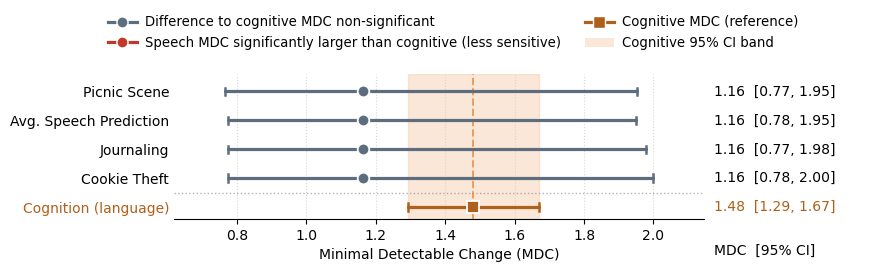

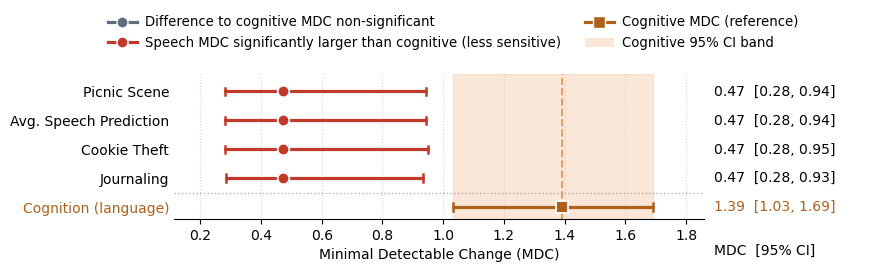

In [37]:
task_replacement = {
    'journaling': 'Journaling',
    'cookieTheft': 'Cookie Theft',
    'picnicScene': 'Picnic Scene',
    'avg_speech_prediction': 'Avg. Speech Prediction',
}


def ci(dist, alpha=0.05):
    lo, hi = np.percentile(dist, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lo, hi


def classify_by_ci(speech_lo, speech_hi, cog_lo, cog_hi):
    """Compare a speech CI to the cognitive CI band."""
    if speech_hi < cog_lo:
        return "better"
    if speech_lo > cog_hi:
        return "worse"
    return "overlap"


def make_classifier(bootstrap_test_res):
    """Closure over a cohort-specific bootstrap test dataframe."""
    def classify(task):
        if bootstrap_test_res.loc[task, 'excludes_zero']:
            return 'worse'
        else:
            return 'overlap'
    return classify


def forest_plot(df, classify_fn, title_suffix='', figsize=None, xlim=None):
    tasks = df.index.tolist()
    n = len(tasks)

    speech_vals = df["mdc_speech_latent"].values.astype(float)
    speech_ci = np.array([ci(d) for d in df["mdc_speech_latent_bootstrap_dist"]])

    cog_val = float(df["mdc_cognitive"].iloc[0])
    cog_lo, cog_hi = ci(df["mdc_cognition_bootstrap_dist_all"].iloc[0])

    # Sort speech tasks so smallest MDC ends up closest to the cognition row.
    order = np.argsort(speech_vals)[::-1]
    tasks = [tasks[i] for i in order]
    tasks_renamed = [task_replacement.get(t, t) for t in tasks]
    speech_vals = speech_vals[order]
    speech_ci = speech_ci[order]

    C = {
        "better":   "#1E8449",
        "overlap":  "#5D6D7E",
        "worse":    "#C0392B",
        "cog":      "#E67E22",
        "cog_dark": "#AF601A",
        "cog_band": "#F5CBA7",
    }

    if figsize is None:
        figsize = (11, max(4.5, 0.6 * (n + 1) + 3.0))
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        2, 2,
        width_ratios=[3.3, 1.0],
        height_ratios=[0.15, 1],
        hspace=0.5, wspace=0.02,
        figure=fig,
    )
    ax = fig.add_subplot(gs[1, 0])
    ax_tbl = fig.add_subplot(gs[1, 1], sharey=ax)
    ax_leg = fig.add_subplot(gs[0, :])
    ax_leg.axis("off")

    # Rows 0..n-1 = speech tasks (top). Row n = cognition (bottom).
    y_speech = np.arange(n)
    y_cog = n

    # Reference band + line for cognitive CI (spans full plot).
    ax.axvspan(cog_lo, cog_hi, color=C["cog_band"], alpha=0.45, zorder=1)
    ax.axvline(cog_val, color=C["cog"], linestyle="--", linewidth=1.4,
               alpha=0.7, zorder=2)

    # Separator between speech tasks and cognition reference row.
    ax.axhline(n - 0.5, color="gray", linestyle=":", linewidth=1, alpha=0.6,
               zorder=1)

    # Speech CIs + point estimates
    for yi, val, (lo, hi), task in zip(y_speech, speech_vals, speech_ci, tasks):
        color = C[classify_fn(task)]
        ax.plot([lo, hi], [yi, yi], color=color, linewidth=2.3,
                solid_capstyle="round", zorder=3)
        ax.plot([lo, lo], [yi - 0.13, yi + 0.13], color=color, linewidth=1.8, zorder=3)
        ax.plot([hi, hi], [yi - 0.13, yi + 0.13], color=color, linewidth=1.8, zorder=3)
        ax.scatter([val], [yi], s=70, color=color,
                   edgecolor="white", linewidth=1.3, zorder=4)

    # Cognition row — square marker in orange to distinguish from speech circles
    ax.plot([cog_lo, cog_hi], [y_cog, y_cog], color=C["cog_dark"],
            linewidth=2.3, solid_capstyle="round", zorder=3)
    ax.plot([cog_lo, cog_lo], [y_cog - 0.13, y_cog + 0.13],
            color=C["cog_dark"], linewidth=1.8, zorder=3)
    ax.plot([cog_hi, cog_hi], [y_cog - 0.13, y_cog + 0.13],
            color=C["cog_dark"], linewidth=1.8, zorder=3)
    ax.scatter([cog_val], [y_cog], s=70, color=C["cog_dark"], marker="s",
               edgecolor="white", linewidth=1.3, zorder=4)

    # Y-axis: task labels + cognition label
    ax.set_yticks(list(y_speech) + [y_cog])
    ax.set_yticklabels(tasks_renamed + [f"Cognition ({target})"])
    yticklabels = ax.get_yticklabels()
    yticklabels[-1].set_color(C["cog_dark"])

    ax.set_ylim(-0.6, n + 0.4)
    ax.invert_yaxis()

    if xlim is None:
        all_lo = min(speech_ci[:, 0].min(), cog_lo)
        all_hi = max(speech_ci[:, 1].max(), cog_hi)
        pad = 0.12 * (all_hi - all_lo)
        xlim = (max(0, all_lo - pad), all_hi + pad)
    ax.set_xlim(*xlim)
    ax.set_xlabel("Minimal Detectable Change (MDC)")
    if title_suffix:
        ax.set_title(title_suffix, loc='left', fontsize=10)

    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0)

    # Numeric column
    ax_tbl.set_xlim(0, 1)
    ax_tbl.set_ylim(ax.get_ylim())
    ax_tbl.axis("off")
    ax_tbl.text(0.02, y_cog + 1.5, "MDC  [95% CI]",
                fontsize=10, fontweight="normal", va="center", ha="left")
    for yi, val, (lo, hi) in zip(y_speech, speech_vals, speech_ci):
        ax_tbl.text(0.02, yi, f"{val:.2f}  [{lo:.2f}, {hi:.2f}]",
                    fontsize=10, va="center", ha="left")
    ax_tbl.text(0.02, y_cog,
                f"{cog_val:.2f}  [{cog_lo:.2f}, {cog_hi:.2f}]",
                fontsize=10, va="center", ha="left",
                fontweight="normal", color=C["cog_dark"])

    # Legend strip on top
    legend_elements = [
        Line2D([0], [0], marker="o", color=C["overlap"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Difference to cognitive MDC non-significant"),
        Line2D([0], [0], marker="o", color=C["worse"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Speech MDC significantly larger than cognitive (less sensitive)"),
        Line2D([0], [0], marker="s", color=C["cog_dark"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Cognitive MDC (reference)"),
        Patch(facecolor=C["cog_band"], alpha=0.45, label="Cognitive 95% CI band"),
    ]
    ax_leg.legend(
        handles=legend_elements, frameon=False, fontsize=9.5,
        loc="center",
        bbox_to_anchor=[0.4, 0],
        ncol=2,
        handlelength=2.2, columnspacing=1.8, handletextpad=0.6,
    )

    return fig, ax


for label, wave_a, wave_b in COHORTS:
    classify_fn = make_classifier(bootstrap_test_by_cohort[label])
    df_for_plot = mdc_results_by_cohort[label].query(
        "task != 'avg_cookieTheft_picnicScene'"
    )
    fig, ax = forest_plot(
        df_for_plot, classify_fn,
        #title_suffix=f'Cohort {label}: {wave_a} ↔ {wave_b}',
        figsize=(9, 2.7),
    )
    plt.savefig(f"plots/MDC_{target}_{VERSION}_cohort{label}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## Bootstrap test — LaTeX tables (one per cohort)

In [38]:
for label, wave_a, wave_b in COHORTS:
    bootstrap_test_res = bootstrap_test_by_cohort[label]
    bootstrap_test_beautified = bootstrap_test_res.copy().loc[
        ~bootstrap_test_res.index.str.startswith("avg_cookieTheft_picnicScene")
    ].copy()
    bootstrap_test_beautified['ci'] = bootstrap_test_beautified.apply(
        lambda row: f"{row['ci_low']:.2f} -- {row['ci_high']:.2f}", axis=1,
    )
    bootstrap_test_beautified['prop_speech_worse'] = bootstrap_test_beautified['prop_speech_worse'].apply(lambda frac: f"{frac:.1%}")
    bootstrap_test_beautified = bootstrap_test_beautified[
        ['mean_diff', 'ci', 'prop_speech_worse', 'excludes_zero']
    ].rename(
        columns={
            'mean_diff': 'Mean Diff',
            'ci_low': '95% CI Low',
            'ci_high': '95% CI High',
            'ci': '95% CI',
            'prop_speech_worse': '\\shortstack[l]{% Speech\\\\MDC larger}',
            'excludes_zero': '\\shortstack[l]{Significant\\\\difference}',
        },
        index={t: task_replacement.get(t, t) for t in bootstrap_test_beautified.index},
    )
    bootstrap_test_beautified.index.name = None

    bootstrap_test_rest_latex = bootstrap_test_beautified.to_latex(
        float_format="%.2f",
        column_format="lcccccc",
        label=f"tab:mdc_bootstrap_test_rest_cohort{label}",
        caption=(
            f"Bootstrap test results assessing if the speech-based MDC is significantly larger than cognitive MDC on Cohort {label}. We report the mean difference in MDCs across {n_bootsrap_samples} bootstrap replicates, the 95% CI of the difference, and the proportion of replicates where speech MDC is larger (worse) than cognitive MDC."
        ),
    ).replace("%", "\\%")
    print(f'\n% === MDC stats results: Cohort {label} ({now()}) ===')
    print(bootstrap_test_rest_latex)


% === MDC stats results: Cohort A (2026-09-22 11:52) ===
\begin{table}
\caption{Bootstrap test results assessing if the speech-based MDC is significantly larger than cognitive MDC on Cohort A. We report the mean difference in MDCs across 10000 bootstrap replicates, the 95\% CI of the difference, and the proportion of replicates where speech MDC is larger (worse) than cognitive MDC.}
\label{tab:mdc_bootstrap_test_rest_cohortA}
\begin{tabular}{lcccccc}
\toprule
 & Mean Diff & 95\% CI & \shortstack[l]{\% Speech\\MDC larger} & \shortstack[l]{Significant\\difference} \\
\midrule
Cookie Theft & -0.26 & -0.79 -- 0.55 & 18.0\% & False \\
Picnic Scene & -0.27 & -0.79 -- 0.51 & 17.9\% & False \\
Journaling & -0.27 & -0.78 -- 0.54 & 17.5\% & False \\
Avg. Speech Prediction & -0.26 & -0.78 -- 0.53 & 18.1\% & False \\
\bottomrule
\end{tabular}
\end{table}


% === MDC stats results: Cohort B (2026-09-22 11:52) ===
\begin{table}
\caption{Bootstrap test results assessing if the speech-based MDC is si

## SEM — four-indicator measurement model

In [39]:
sem_tasks = ['cookieTheft', 'picnicScene', 'journaling']

def fit_four_indicator_sem(dat, model_type="full"):
    """
    Fit one of seven measurement models to four indicators per participant
    (y1, y2, hat_y1, hat_y2).

    Baseline ("full") assumes:
      - time-invariant attenuation lam on hat_y,
      - stable speaker bias b, orthogonal to C, with unit loadings on hat_y,
      - stationary residual variances (v1 for y, ve for hat_y),
      - independent residuals across waves.
    """
    specs = {
        "full": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "no_attenuation": """
            c =~ 1*y1 + 1*y2 + 1*hat_y1 + 1*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "no_beta": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
        """,
        "no_attenuation_no_beta": """
            c =~ 1*y1 + 1*y2 + 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
        """,
        "correlated_hat_residuals": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            hat_y1 ~~ rh*hat_y2
            c ~~ c
        """,
        "free_hat_resid_by_wave": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve1*hat_y1
            hat_y2 ~~ ve2*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "free_y_resid_by_wave": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v2*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
    }

    if model_type not in specs:
        raise ValueError(f"Unknown model_type: {model_type}")

    sem_desc = specs[model_type]
    try:
        model = Model(sem_desc, mimic_lavaan=True)
        model.fit(dat)
        fit_stats = calc_stats(model)

        # manual srmr calculation, checked against R's lavaan implementation
        obs_vars = model.vars['observed']
        S = dat[obs_vars].cov().values
        n = dat.shape[0]
        S = S * (n - 1) / n  # match lavaan's ML sample cov
        Sigma, _ = model.calc_sigma()
        inv_std = np.diag(1 / np.sqrt(np.diag(S)))
        S_std = inv_std @ S @ inv_std
        Sigma_std = inv_std @ Sigma @ inv_std
        R = S_std - Sigma_std
        idx = np.tril_indices_from(R)
        residuals = R[idx]
        srmr = np.sqrt(np.mean(residuals**2))
        fit_stats["SRMR"] = srmr

        fit_stats = fit_stats.T if hasattr(fit_stats, "T") else fit_stats
        return {
            "model_type": model_type,
            "model_syntax": sem_desc,
            "parameter_estimates": model.inspect(),
            "fit_stats": fit_stats,
        }
    except Exception as e:
        print(f"error fitting {model_type}:", str(e))
        return {"model_type": model_type, "model_syntax": sem_desc, "error": str(e)}


def lr_test(restricted, unrestricted):
    """
    Chi-square difference (likelihood-ratio) test for nested SEM models.
    """
    if "error" in restricted or "error" in unrestricted:
        return {"delta_chi2": np.nan, "delta_df": np.nan, "p_value": np.nan}
    chi2_r = float(restricted["fit_stats"].loc["chi2", "Value"])
    chi2_u = float(unrestricted["fit_stats"].loc["chi2", "Value"])
    df_r   = float(restricted["fit_stats"].loc["DoF",  "Value"])
    df_u   = float(unrestricted["fit_stats"].loc["DoF",  "Value"])
    delta_chi2 = chi2_r - chi2_u
    delta_df   = df_r - df_u
    p_value    = 1 - chi2_dist.cdf(delta_chi2, delta_df) if delta_df > 0 else np.nan
    return {"delta_chi2": delta_chi2, "delta_df": int(delta_df), "p_value": p_value}


model_names = [
    "full",
    "no_attenuation",
    "no_beta",
    "no_attenuation_no_beta",
    #"correlated_hat_residuals",
    "free_hat_resid_by_wave",
    "free_y_resid_by_wave",
]

lr_pairs = [
    ("no_attenuation",          "full"),
    ("no_beta",                 "full"),
    ("no_attenuation_no_beta",  "full"),
    ("full", "free_hat_resid_by_wave"),
    ("full", "free_y_resid_by_wave"),
]

fit_stats_to_report = ["chi2", "chi2 p-value", "DoF", "CFI", "TLI", 'SRMR']


def run_sem_for_cohort(longitudinal, wave_a, wave_b, sem_tasks, target):
    target_a_col = (wave_a, target, 'target')
    target_b_col = (wave_b, target, 'target')
    task_fit_dfs = []
    task_lr_dfs = []

    for task in sem_tasks:
        df_here = longitudinal[[
            target_a_col, target_b_col,
            (wave_a, target, task), (wave_b, target, task),
        ]].dropna().copy()
        df_here.columns = ['y1', 'y2', 'hat_y1', 'hat_y2']

        models = {name: fit_four_indicator_sem(df_here, name) for name in model_names}

        fit_rows = {}
        for name, m in models.items():
            if 'error' in m:
                fit_rows[name] = {k: np.nan for k in fit_stats_to_report}
            else:
                fit_rows[name] = m['fit_stats'].loc[fit_stats_to_report, 'Value'].to_dict()
        task_fit_dfs.append(pd.DataFrame(fit_rows))

        lr_rows = {
            f'{restricted} vs {unrestricted}':
                lr_test(models[restricted], models[unrestricted])
            for restricted, unrestricted in lr_pairs
        }
        task_lr_dfs.append(pd.DataFrame(lr_rows).T)

    sem_fit_df = pd.concat(task_fit_dfs, keys=sem_tasks)
    sem_lr_df  = pd.concat(task_lr_dfs,  keys=sem_tasks)
    sem_lr_df['p_value'] = sem_lr_df['p_value'].round(6)
    return sem_fit_df, sem_lr_df


sem_results_by_cohort = {}
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) — fitting SEM models ===')
    sem_fit_df, sem_lr_df = run_sem_for_cohort(
        longitudinal_by_cohort[label], wave_a, wave_b, sem_tasks, target,
    )
    sem_results_by_cohort[label] = (sem_fit_df, sem_lr_df)
    results[label]['sem_fit_df'] = sem_fit_df
    results[label]['sem_lr_df'] = sem_lr_df

sem_results_by_cohort['A'][0]


=== Cohort A (wave1 ↔ wave2) — fitting SEM models ===

=== Cohort B (wave2 ↔ wave3) — fitting SEM models ===


full  no_attenuation     no_beta  \
cookieTheft chi2          1.419383      166.783450  838.409796   
            chi2 p-value  0.922181        0.000000    0.000000   
            DoF           5.000000        6.000000    6.000000   
            CFI           1.003324        0.850757    0.227338   
            TLI           1.005318        0.801009   -0.030216   
            SRMR          0.008338        0.200175    0.258823   
picnicScene chi2          1.421144      166.822844  838.382812   
            chi2 p-value  0.921986        0.000000    0.000000   
            DoF           5.000000        6.000000    6.000000   
            CFI           1.003322        0.850716    0.227342   
            TLI           1.005315        0.800955   -0.030210   
            SRMR          0.008341        0.200225    0.258822   
journaling  chi2          1.418227      166.818422  838.407507   
            chi2 p-value  0.922309        0.000000    0.000000   
            DoF           5.000000        6.000000    6.000000   
            CFI           1.003325        0.850724    0.227337   
            TLI           1.005320        0.800965   -0.030217   
            SRMR          0.008340        0.200167    0.258822   

                          no_attenuation_no_beta  free_hat_resid_by_wave  \
cookieTheft chi2                      173.580937                0.847317   
            chi2 p-value                0.000000                0.931994   
            DoF                         7.000000                4.000000   
            CFI                         0.845376                1.002924   
            TLI                         0.823287                1.005117   
            SRMR                        0.192302                0.006959   
picnicScene chi2                      173.565001                0.848345   
            chi2 p-value                0.000000                0.931852   
            DoF                         7.000000                4.000000   
            CFI                         0.845386                1.002923   
            TLI                         0.823299                1.005115   
            SRMR                        0.192343                0.006964   
journaling  chi2                      173.562972                0.847147   
            chi2 p-value                0.000000                0.932018   
            DoF                         7.000000                4.000000   
            CFI                         0.845392                1.002924   
            TLI                         0.823305                1.005117   
            SRMR                        0.192343                0.006964   

                          free_y_resid_by_wave  
cookieTheft chi2                      1.324295  
            chi2 p-value              0.857240  
            DoF                       4.000000  
            CFI                       1.002481  
            TLI                       1.004343  
            SRMR                      0.005402  
picnicScene chi2                      1.325834  
            chi2 p-value              0.856977  
            DoF                       4.000000  
            CFI                       1.002480  
            TLI                       1.004340  
            SRMR                      0.005392  
journaling  chi2                      1.323111  
            chi2 p-value              0.857442  
            DoF                       4.000000  
            CFI                       1.002483  
            TLI                       1.004345  
            SRMR                      0.005398

In [40]:
sem_results_by_cohort['B'][0]

full  no_attenuation       no_beta  \
cookieTheft chi2          6.188908    5.218929e+01  4.369672e+01   
            chi2 p-value  0.288269    1.708311e-09  8.489638e-08   
            DoF           5.000000    6.000000e+00  6.000000e+00   
            CFI           0.996325    8.572322e-01  8.834822e-01   
            TLI           0.994120    8.096430e-01  8.446429e-01   
            SRMR          0.024685    2.574938e-01  1.629383e-01   
picnicScene chi2          6.189860    5.220870e+01  4.369970e+01   
            chi2 p-value  0.288181    1.693028e-09  8.478085e-08   
            DoF           5.000000    6.000000e+00  6.000000e+00   
            CFI           0.996322    8.571611e-01  8.834638e-01   
            TLI           0.994115    8.095481e-01  8.446184e-01   
            SRMR          0.024687    2.576260e-01  1.629995e-01   
journaling  chi2          6.189497    5.221224e+01  4.369580e+01   
            chi2 p-value  0.288214    1.690249e-09  8.493205e-08   
            DoF           5.000000    6.000000e+00  6.000000e+00   
            CFI           0.996324    8.571681e-01  8.834906e-01   
            TLI           0.994118    8.095575e-01  8.446541e-01   
            SRMR          0.024677    2.576399e-01  1.629991e-01   

                          no_attenuation_no_beta  free_hat_resid_by_wave  \
cookieTheft chi2                    5.218929e+01                3.591255   
            chi2 p-value            5.357879e-09                0.464139   
            DoF                     7.000000e+00                4.000000   
            CFI                     8.603232e-01                1.001260   
            TLI                     8.403693e-01                1.002205   
            SRMR                    2.575135e-01                0.023822   
picnicScene chi2                    5.220872e+01                3.591832   
            chi2 p-value            5.310829e-09                0.464053   
            DoF                     7.000000e+00                4.000000   
            CFI                     8.602522e-01                1.001258   
            TLI                     8.402882e-01                1.002202   
            SRMR                    2.575415e-01                0.023815   
journaling  chi2                    5.221226e+01                3.591429   
            chi2 p-value            5.302308e-09                0.464113   
            DoF                     7.000000e+00                4.000000   
            CFI                     8.602589e-01                1.001259   
            TLI                     8.402959e-01                1.002204   
            SRMR                    2.576159e-01                0.023837   

                          free_y_resid_by_wave  
cookieTheft chi2                      5.620908  
            chi2 p-value              0.229304  
            DoF                       4.000000  
            CFI                       0.995004  
            TLI                       0.991256  
            SRMR                      0.018875  
picnicScene chi2                      5.621484  
            chi2 p-value              0.229256  
            DoF                       4.000000  
            CFI                       0.995002  
            TLI                       0.991253  
            SRMR                      0.018901  
journaling  chi2                      5.622023  
            chi2 p-value              0.229210  
            DoF                       4.000000  
            CFI                       0.995000  
            TLI                       0.991251  
            SRMR                      0.018892

In [41]:
for label, _, _ in COHORTS:
    print(f'\n=== Cohort {label} — LR tests ===')
    display(sem_results_by_cohort[label][1])


=== Cohort A — LR tests ===


delta_chi2  delta_df   p_value
cookieTheft no_attenuation vs full          165.364067       1.0  0.000000
            no_beta vs full                 836.990414       1.0  0.000000
            no_attenuation_no_beta vs full  172.161554       2.0  0.000000
            full vs free_hat_resid_by_wave    0.572066       1.0  0.449439
            full vs free_y_resid_by_wave      0.095088       1.0  0.757805
picnicScene no_attenuation vs full          165.401699       1.0  0.000000
            no_beta vs full                 836.961667       1.0  0.000000
            no_attenuation_no_beta vs full  172.143856       2.0  0.000000
            full vs free_hat_resid_by_wave    0.572799       1.0  0.449149
            full vs free_y_resid_by_wave      0.095311       1.0  0.757531
journaling  no_attenuation vs full          165.400195       1.0  0.000000
            no_beta vs full                 836.989281       1.0  0.000000
            no_attenuation_no_beta vs full  172.144745       2.0  0.000000
            full vs free_hat_resid_by_wave    0.571079       1.0  0.449830
            full vs free_y_resid_by_wave      0.095116       1.0  0.757771


=== Cohort B — LR tests ===


delta_chi2  delta_df   p_value
cookieTheft no_attenuation vs full           46.000386       1.0  0.000000
            no_beta vs full                  37.507811       1.0  0.000000
            no_attenuation_no_beta vs full   46.000383       2.0  0.000000
            full vs free_hat_resid_by_wave    2.597653       1.0  0.107022
            full vs free_y_resid_by_wave      0.568001       1.0  0.451054
picnicScene no_attenuation vs full           46.018837       1.0  0.000000
            no_beta vs full                  37.509843       1.0  0.000000
            no_attenuation_no_beta vs full   46.018861       2.0  0.000000
            full vs free_hat_resid_by_wave    2.598028       1.0  0.106997
            full vs free_y_resid_by_wave      0.568377       1.0  0.450905
journaling  no_attenuation vs full           46.022747       1.0  0.000000
            no_beta vs full                  37.506301       1.0  0.000000
            no_attenuation_no_beta vs full   46.022761       2.0  0.000000
            full vs free_hat_resid_by_wave    2.598068       1.0  0.106994
            full vs free_y_resid_by_wave      0.567474       1.0  0.451264

## SEM — LaTeX tables (one per cohort)

In [42]:
def format_p(p):
    """Format p-values: '<0.001' for very small, else 3 decimals."""
    if pd.isna(p):
        return "---"
    if p < 0.001:
        return "$<0.001$"
    return f"{p:.3f}"


def format_num(x, decimals=3):
    if pd.isna(x):
        return "---"
    return f"{x:.{decimals}f}"


model_display_names = {
    "full":                     r"Full",
    "no_attenuation":           r"\shortstack{No atten.\\($\lambda=1$)} ",
    "no_beta":                  r"\shortstack{No bias\\($\beta$ dropped)} ",
    "no_attenuation_no_beta":   r"\shortstack{No atten.\\no bias} ",
    "correlated_hat_residuals": r"Correlated $\hat{Y}$ residuals",
    "free_hat_resid_by_wave":   r"\shortstack{Free $\sigma_\epsilon^2$\\by wave}",
    "free_y_resid_by_wave":     r"\shortstack{Free $\sigma_\delta^2$\\by wave}",
}

fit_stat_display_names = {
    "chi2":         r"$\chi^2$",
    "DoF":          r"df",
    "chi2 p-value": r"$p(\chi^2)$",
    "CFI":          r"CFI",
    "TLI":          r"TLI",
    "RMSEA":        r"RMSEA",
    "AIC":          r"AIC",
    "BIC":          r"BIC",
    "SRMR":         r"SRMR",
}

task_display_names = {
    "cookieTheft":                 r"Cookie Theft",
    "picnicScene":                 r"Picnic Scene",
    "journaling":                  r"Journaling",
    "avg_speech_prediction":       r"Avg.\ (all tasks)",
    "avg_cookieTheft_picnicScene": r"Avg.\ (Cookie Theft + Picnic Scene)",
}


def fit_df_to_latex(sem_fit_df, caption=None, label='tab:sem_fit'):
    df = sem_fit_df.copy()

    formatted = df.copy().astype(object)
    for (task, stat) in df.index:
        for col in df.columns:
            val = df.loc[(task, stat), col]
            if stat == 'chi2 p-value':
                formatted.loc[(task, stat), col] = format_p(val)
            elif stat in ('chi2', 'AIC', 'BIC'):
                formatted.loc[(task, stat), col] = format_num(val, 1)
            elif stat == 'DoF':
                formatted.loc[(task, stat), col] = (
                    '---' if pd.isna(val) else f'{int(val)}'
                )
            else:
                formatted.loc[(task, stat), col] = format_num(val, 3)

    formatted.index = pd.MultiIndex.from_tuples(
        [(task_display_names.get(t, t), fit_stat_display_names.get(s, s))
         for (t, s) in formatted.index],
        names=['Task', 'Statistic'],
    )
    formatted.columns = [model_display_names.get(c, c) for c in formatted.columns]

    latex = formatted.to_latex(
        escape=False,
        multirow=True,
        column_format='ll' + 'r' * len(formatted.columns),
        caption=caption or (
            "Absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. "
        ),
        label=label,
    )
    return latex


def lr_df_to_latex(sem_lr_df, caption=None, label='tab:sem_lr'):
    df = sem_lr_df.copy()

    formatted = pd.DataFrame(index=df.index, columns=df.columns, dtype=object)
    for idx in df.index:
        formatted.loc[idx, 'delta_chi2'] = format_num(df.loc[idx, 'delta_chi2'], 3)
        dd = df.loc[idx, 'delta_df']
        formatted.loc[idx, 'delta_df'] = '---' if pd.isna(dd) else f'{int(dd)}'
        formatted.loc[idx, 'p_value']  = format_p(df.loc[idx, 'p_value'])

    comparison_display = {
        'no_attenuation vs full':         r'$\lambda=1$ vs.\ Full',
        'no_beta vs full':                r'No $\beta$ vs.\ Full',
        'no_attenuation_no_beta vs full': r'$\lambda=1$, no $\beta$ vs.\ Full',
        'full vs free_hat_resid_by_wave': r'Full vs.\ free $\sigma_\epsilon^2$ by wave',
        'full vs free_y_resid_by_wave':   r'Full vs.\ free $\sigma_\delta^2$ by wave',
    }

    formatted.index = pd.MultiIndex.from_tuples(
        [(task_display_names.get(t, t), comparison_display.get(c, c))
         for (t, c) in formatted.index],
        names=['Task', 'Comparison'],
    )
    formatted.columns = [r'$\Delta\chi^2$', r'$\Delta$df', r'$p$']

    latex = formatted.to_latex(
        escape=False,
        multirow=True,
        column_format='llrrr',
        caption=caption,
        label=label,
    )
    return latex


for label, wave_a, wave_b in COHORTS:
    sem_fit_df, sem_lr_df = sem_results_by_cohort[label]

    fit_caption = (
        f"Cohort {label}: absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. Lower $\\chi^2$, AIC, and BIC indicate better fit; CFI and TLI above 0.95 and RMSEA below 0.08 indicate acceptable fit."
    )
    lr_caption = (
        f"Cohort {label}: likelihood-ratio tests for the nested model comparisons. For the three nested alternatives (top three rows per task), a significant $p$-value rejects the alternative in favor of the full model, confirming that $\\lambda < 1$ and $\\beta \\neq 0$ are carrying real variance. For the two stationarity relaxations (bottom two rows per task), a non-significant $p$-value is consistent with the assumption of stationary residual variances."
    )

    fit_latex = fit_df_to_latex(
        sem_fit_df, caption=fit_caption, label=f'tab:sem_fit_cohort{label}',
    ).replace(r'\cline', r'\cmidrule')
    lr_latex = lr_df_to_latex(
        sem_lr_df, caption=lr_caption, label=f'tab:sem_lr_cohort{label}',
    ).replace(r'\cline', r'\cmidrule')

    print(f'\n% === Cohort {label}: fit indices ({now()}) ===')
    print(fit_latex)
    print(f'\n% === Cohort {label}: LR tests  ({now()}) ===')
    print(lr_latex)


% === Cohort A: fit indices (2026-09-22 11:52) ===
\begin{table}
\caption{Cohort A: absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. Lower $\chi^2$, AIC, and BIC indicate better fit; CFI and TLI above 0.95 and RMSEA below 0.08 indicate acceptable fit.}
\label{tab:sem_fit_cohortA}
\begin{tabular}{llrrrrrr}
\toprule
 &  & Full & \shortstack{No atten.\\($\lambda=1$)}  & \shortstack{No bias\\($\beta$ dropped)}  & \shortstack{No atten.\\no bias}  & \shortstack{Free $\sigma_\epsilon^2$\\by wave} & \shortstack{Free $\sigma_\delta^2$\\by wave} \\
Task & Statistic &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{Cookie Theft} & $\chi^2$ & 1.4 & 166.8 & 838.4 & 173.6 & 0.8 & 1.3 \\
 & $p(\chi^2)$ & 0.922 & $<0.001$ & $<0.001$ & $<0.001$ & 0.932 & 0.857 \\
 & df & 5 & 6 & 6 & 7 & 4 & 4 \\
 & CFI & 1.003 & 0.851 & 0.227 & 0.845 & 1.003 & 1.002 \\
 & TLI & 1.005 & 0.801 & 

In [43]:
def emit_full_model_summary(sem_fit_df, label, wave_a, wave_b):
    full_only = sem_fit_df['full'].unstack(level=1)
    stat_order = ['chi2', 'DoF', 'chi2 p-value', 'CFI', 'TLI', 'SRMR']
    full_only = full_only[stat_order]
    full_only.columns = [fit_stat_display_names.get(c, c) for c in full_only.columns]
    full_only.index = [task_display_names.get(t, t) for t in full_only.index]
    full_only.index.name = 'Task'

    def format_full_row(row):
        out = {}
        out[r'df']           = '---' if pd.isna(row[r'df']) else f"{int(row[r'df'])}"
        out[r'$\chi^2$']     = format_num(row[r'$\chi^2$'], 1)
        out[r'$p(\chi^2)$']  = format_p(row[r'$p(\chi^2)$'])
        out[r'CFI']          = format_num(row[r'CFI'], 3)
        out[r'TLI']          = format_num(row[r'TLI'], 3)
        out[r'SRMR']         = format_num(row[r'SRMR'], 3)
        return pd.Series(out)

    full_formatted = full_only.apply(format_full_row, axis=1)

    full_latex = full_formatted.to_latex(
        escape=False,
        multirow=False,
        column_format='l' + 'r' * len(full_formatted.columns),
        caption=(
            f"Cohort {label}: absolute fit indices of the speech measurement model for each speech task and the \\textit{{target}} composite score. CFI and TLI above 0.95 and SRMR below 0.08 indicate adequate fit. Fit indices for the five alternative models and the corresponding likelihood-ratio tests are reported in the supplementary material (Tables~\\ref{{tab:sem_fit_cohort{label}}} and \\ref{{tab:sem_lr_cohort{label}}})."
        ),
        label=f'tab:sem_fit_{target}_full_cohort{label}',
    )
    return full_latex


for label, wave_a, wave_b in COHORTS:
    sem_fit_df, _ = sem_results_by_cohort[label]
    full_latex = emit_full_model_summary(sem_fit_df, label, wave_a, wave_b)
    print(f'\n% === Cohort {label}: full-model summary {target} ({now()}) ===')
    print(full_latex)



% === Cohort A: full-model summary language (2026-09-22 11:52) ===
\begin{table}
\caption{Cohort A: absolute fit indices of the speech measurement model for each speech task and the \textit{target} composite score. CFI and TLI above 0.95 and SRMR below 0.08 indicate adequate fit. Fit indices for the five alternative models and the corresponding likelihood-ratio tests are reported in the supplementary material (Tables~\ref{tab:sem_fit_cohortA} and \ref{tab:sem_lr_cohortA}).}
\label{tab:sem_fit_language_full_cohortA}
\begin{tabular}{lrrrrrr}
\toprule
 & df & $\chi^2$ & $p(\chi^2)$ & CFI & TLI & SRMR \\
Task &  &  &  &  &  &  \\
\midrule
Cookie Theft & 5 & 1.4 & 0.922 & 1.003 & 1.005 & 0.008 \\
Picnic Scene & 5 & 1.4 & 0.922 & 1.003 & 1.005 & 0.008 \\
Journaling & 5 & 1.4 & 0.922 & 1.003 & 1.005 & 0.008 \\
\bottomrule
\end{tabular}
\end{table}


% === Cohort B: full-model summary language (2026-09-22 11:52) ===
\begin{table}
\caption{Cohort B: absolute fit indices of the speech measureme

In [44]:
# combine important results so we can combine the forest plots for all targets into one (separate analysis file)

flat_summary = {'A': {}, 'B': {}}
for label, _, _ in COHORTS:
    flat_summary[label] = {
        'target': target,
        'version': VERSION,
        "n": results[label]["n"],

        # ICCs
        f"ICC": results[label][f"ICC_{target}"],
        f"ICC_cookieTheft": results[label][f"ICC_{target}_cookieTheft"],
        f"ICC_picnicScene": results[label][f"ICC_{target}_picnicScene"],
        f"ICC_journaling": results[label][f"ICC_{target}_journaling"],
        f"ICC_avg_speech_prediction": results[label][f"ICC_{target}_avg_speech_prediction"],
        #f"ICC_avg_cookieTheft_picnicScene": results[label][f"ICC_{target}_avg_cookieTheft_picnicScene"],
    }

    # Add key MDC metrics
    for task, row in results[label]["mdc"].iterrows():
        #if task != 'avg_speech_prediction':
        #    continue
        flat_summary[label][f"{task}_mdc_cognitive_text"] = row["mdc_cognitive_text"]
        flat_summary[label][f"{task}_mdc_speech_latent"] = row["mdc_speech_latent_text"]
        flat_summary[label][f"{task}_mdc_speech_pred"] = row["mdc_speech_pred_text"]
        flat_summary[label][f"{task}_var_y_obs"] = row["var_y_obs"]
        flat_summary[label][f"{task}_regression_r2"] = row["regression_r2"]
        flat_summary[label][f"{task}_regression_r2_text"] = row["regression_r2_text"]
        flat_summary[label][f"{task}_regression_mse"] = row["regression_mse"]
        flat_summary[label][f"{task}_target_reliability_hat"] = row["target_reliability_hat"]
        flat_summary[label][f"{task}_icc_text"] = row["icc_text"]
        flat_summary[label][f"{task}_icc_cognitive_text"] = row["icc_cognitive_text"]
        flat_summary[label][f"{task}_lambda_hat"] = row["lambda_hat"]
        flat_summary[label][f"{task}_sigma_epsilon_sq_hat"] = row["sigma_epsilon_sq_hat"]


    # Add bootstrap comparison results[label]
    for task, row in results[label]["bootstrap_test"].iterrows():
        #if task != 'avg_speech_prediction':
        #    continue
        flat_summary[label][f"{task}_bootstrap_mean_diff"] = row["mean_diff"]
        flat_summary[label][f"{task}_bootstrap_ci_low"] = row["ci_low"]
        flat_summary[label][f"{task}_bootstrap_ci_high"] = row["ci_high"]
        flat_summary[label][f"{task}_bootstrap_excludes_zero"] = row["excludes_zero"]
        flat_summary[label][f"{task}_bootstrap_prop_speech_worse"] = row["prop_speech_worse"]
        flat_summary[label][f"{task}_significance"] = f'{row["ci_low"]:.2}-{row["ci_high"]:.2}{"*" if row["excludes_zero"] else ""}'

    # SEM fit quality (full model only)
    for task in ["cookieTheft", "picnicScene", "journaling"]:
        fit = results[label]["sem_fit_df"].loc[(task, slice(None)), "full"].reset_index(level=0, drop=True)

        flat_summary[label][f"{task}_sem_chi2"] = fit["chi2"]
        flat_summary[label][f"{task}_sem_chi2_pval"] = fit["chi2 p-value"]
        flat_summary[label][f"{task}_sem_cfi"] = fit["CFI"]
        flat_summary[label][f"{task}_sem_tli"] = fit["TLI"]
        flat_summary[label][f"{task}_sem_srmr"] = fit["SRMR"]
        flat_summary[label][f"{task}_sem_fit"] = f'{fit["chi2"]:.1f}|{fit["chi2 p-value"]:.2f} / {fit["TLI"]:.2} / {fit["CFI"]:.2} / {fit["SRMR"]:.2}'

        flat_summary[label][f"{task}_sem_lr"] = "|".join(results[label]["sem_lr_df"].loc[(task, slice(None)), "p_value"].reset_index(level=0, drop=True).apply(format_p))
        flat_summary[label][f"{task}_sem_lr_full"] = results[label]["sem_lr_df"].to_json(orient="split")

flat_summary_df = pd.DataFrame(flat_summary)
flat_summary_df


,A,B
target,language,language
version,demographics_only,demographics_only
n,305,70
ICC,0.685989,0.718166
ICC_cookieTheft,0.974114,0.986898
...,...,...
journaling_sem_tli,1.00532,0.994118
journaling_sem_srmr,0.00834,0.024677
journaling_sem_fit,1.4|0.92 / 1.0 / 1.0 / 0.0083,6.2|0.29 / 0.99 / 1.0 / 0.025
journaling_sem_lr,$<0.001$|$<0.001$|$<0.001$|0.450|0.758,$<0.001$|$<0.001$|$<0.001$|0.107|0.451


In [45]:
import os
os.makedirs("MDC_results", exist_ok=True)
flat_summary_df.to_csv(f"MDC_results/{target}_{VERSION}.csv")


In [46]:
results[label]['sem_lr_df']

delta_chi2  delta_df   p_value
cookieTheft no_attenuation vs full           46.000386       1.0  0.000000
            no_beta vs full                  37.507811       1.0  0.000000
            no_attenuation_no_beta vs full   46.000383       2.0  0.000000
            full vs free_hat_resid_by_wave    2.597653       1.0  0.107022
            full vs free_y_resid_by_wave      0.568001       1.0  0.451054
picnicScene no_attenuation vs full           46.018837       1.0  0.000000
            no_beta vs full                  37.509843       1.0  0.000000
            no_attenuation_no_beta vs full   46.018861       2.0  0.000000
            full vs free_hat_resid_by_wave    2.598028       1.0  0.106997
            full vs free_y_resid_by_wave      0.568377       1.0  0.450905
journaling  no_attenuation vs full           46.022747       1.0  0.000000
            no_beta vs full                  37.506301       1.0  0.000000
            no_attenuation_no_beta vs full   46.022761       2.0  0.000000
            full vs free_hat_resid_by_wave    2.598068       1.0  0.106994
            full vs free_y_resid_by_wave      0.567474       1.0  0.451264